In [4]:
import warnings
warnings.simplefilter(action="ignore")
warnings.filterwarnings("ignore")   #to remove all little warnings 

from collections import Counter

# Import the necessary packages
import numpy as np  #mathematical library
import pandas as pd  #library used to deal with dataframe 

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Algorithms
from statsmodels.stats.outliers_influence import variance_inflation_factor #for outlier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler  #suppose u have values form 1 to 100 so it converts them in scale of -1 to 1 so that everyone gets equal rating smthg may be in gm kg m so bring them to one standard
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error
from sklearn.metrics import precision_recall_fscore_support

# Data directory #used to set environment in kaggle #no need of it inlocal #gives us path for dataset
import os
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/cherrytodii/maternal-health/Maternal Health Risk Data Set.csv


<div style="background:linear-gradient(90deg,#6a11cb,#2575fc);
padding:20px;
border-radius:15px;">
<h1 align="center" style="color:white;">
🌸 Maternal Health Risk Prediction 🌸
</h1>
</div>

In [5]:
import pandas as pd

m_df = pd.read_csv("/kaggle/input/datasets/cherrytodii/maternal-health/Maternal Health Risk Data Set.csv")

m_df.head()  #csv file upload krne hum pandas ki help lete hai
#head gives u sfirst top 5 files#everthing i sintegre except for risk level

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [6]:
m_df.info()  #there are 1014 data and all non-null so definitely and none of them is null
#,hence our data is clean and valid

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [7]:
print(f"The dataset size: {m_df.shape}")  #to know the row and col
#m_df is our dataframe i.e maternal dataframe

The dataset size: (1014, 7)


In [8]:
print(m_df["RiskLevel"].value_counts())  #by seeing the dataset above we dont know how many risk levels can be there
                                         #so we are finding the count and types of each risk level   i.e 3 levels we find that its quite biased towards low risk
                                        #since we have to predict the risk itself so its important that all this 3 types of risk are even and not biased towards any other decision

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64


In [9]:
m_df.tail() #gives us last 5 data #if in bracket we write 2 then it will only give last 2 values

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk
1013,32,120,65,6.0,101.0,76,mid risk


In [10]:
m_df.describe().T #T stands for transpose and helps to convert row into col and col into rows as per ur convinience whichever u prefer with transpose and without transpose 
                  #helps us know start and end mean std deviation of condn

,count,mean,std,min,25%,50%,75%,max
Age,1014.0,29.871795,13.474386,10.0,19.0,26.0,39.0,70.0
SystolicBP,1014.0,113.198225,18.403913,70.0,100.0,120.0,120.0,160.0
DiastolicBP,1014.0,76.460552,13.885796,49.0,65.0,80.0,90.0,100.0
BS,1014.0,8.725986,3.293532,6.0,6.9,7.5,8.0,19.0
BodyTemp,1014.0,98.665089,1.371384,98.0,98.0,98.0,98.0,103.0
HeartRate,1014.0,74.301775,8.088702,7.0,70.0,76.0,80.0,90.0


In [11]:
m_df.columns


Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
       'RiskLevel'],
      dtype='object')

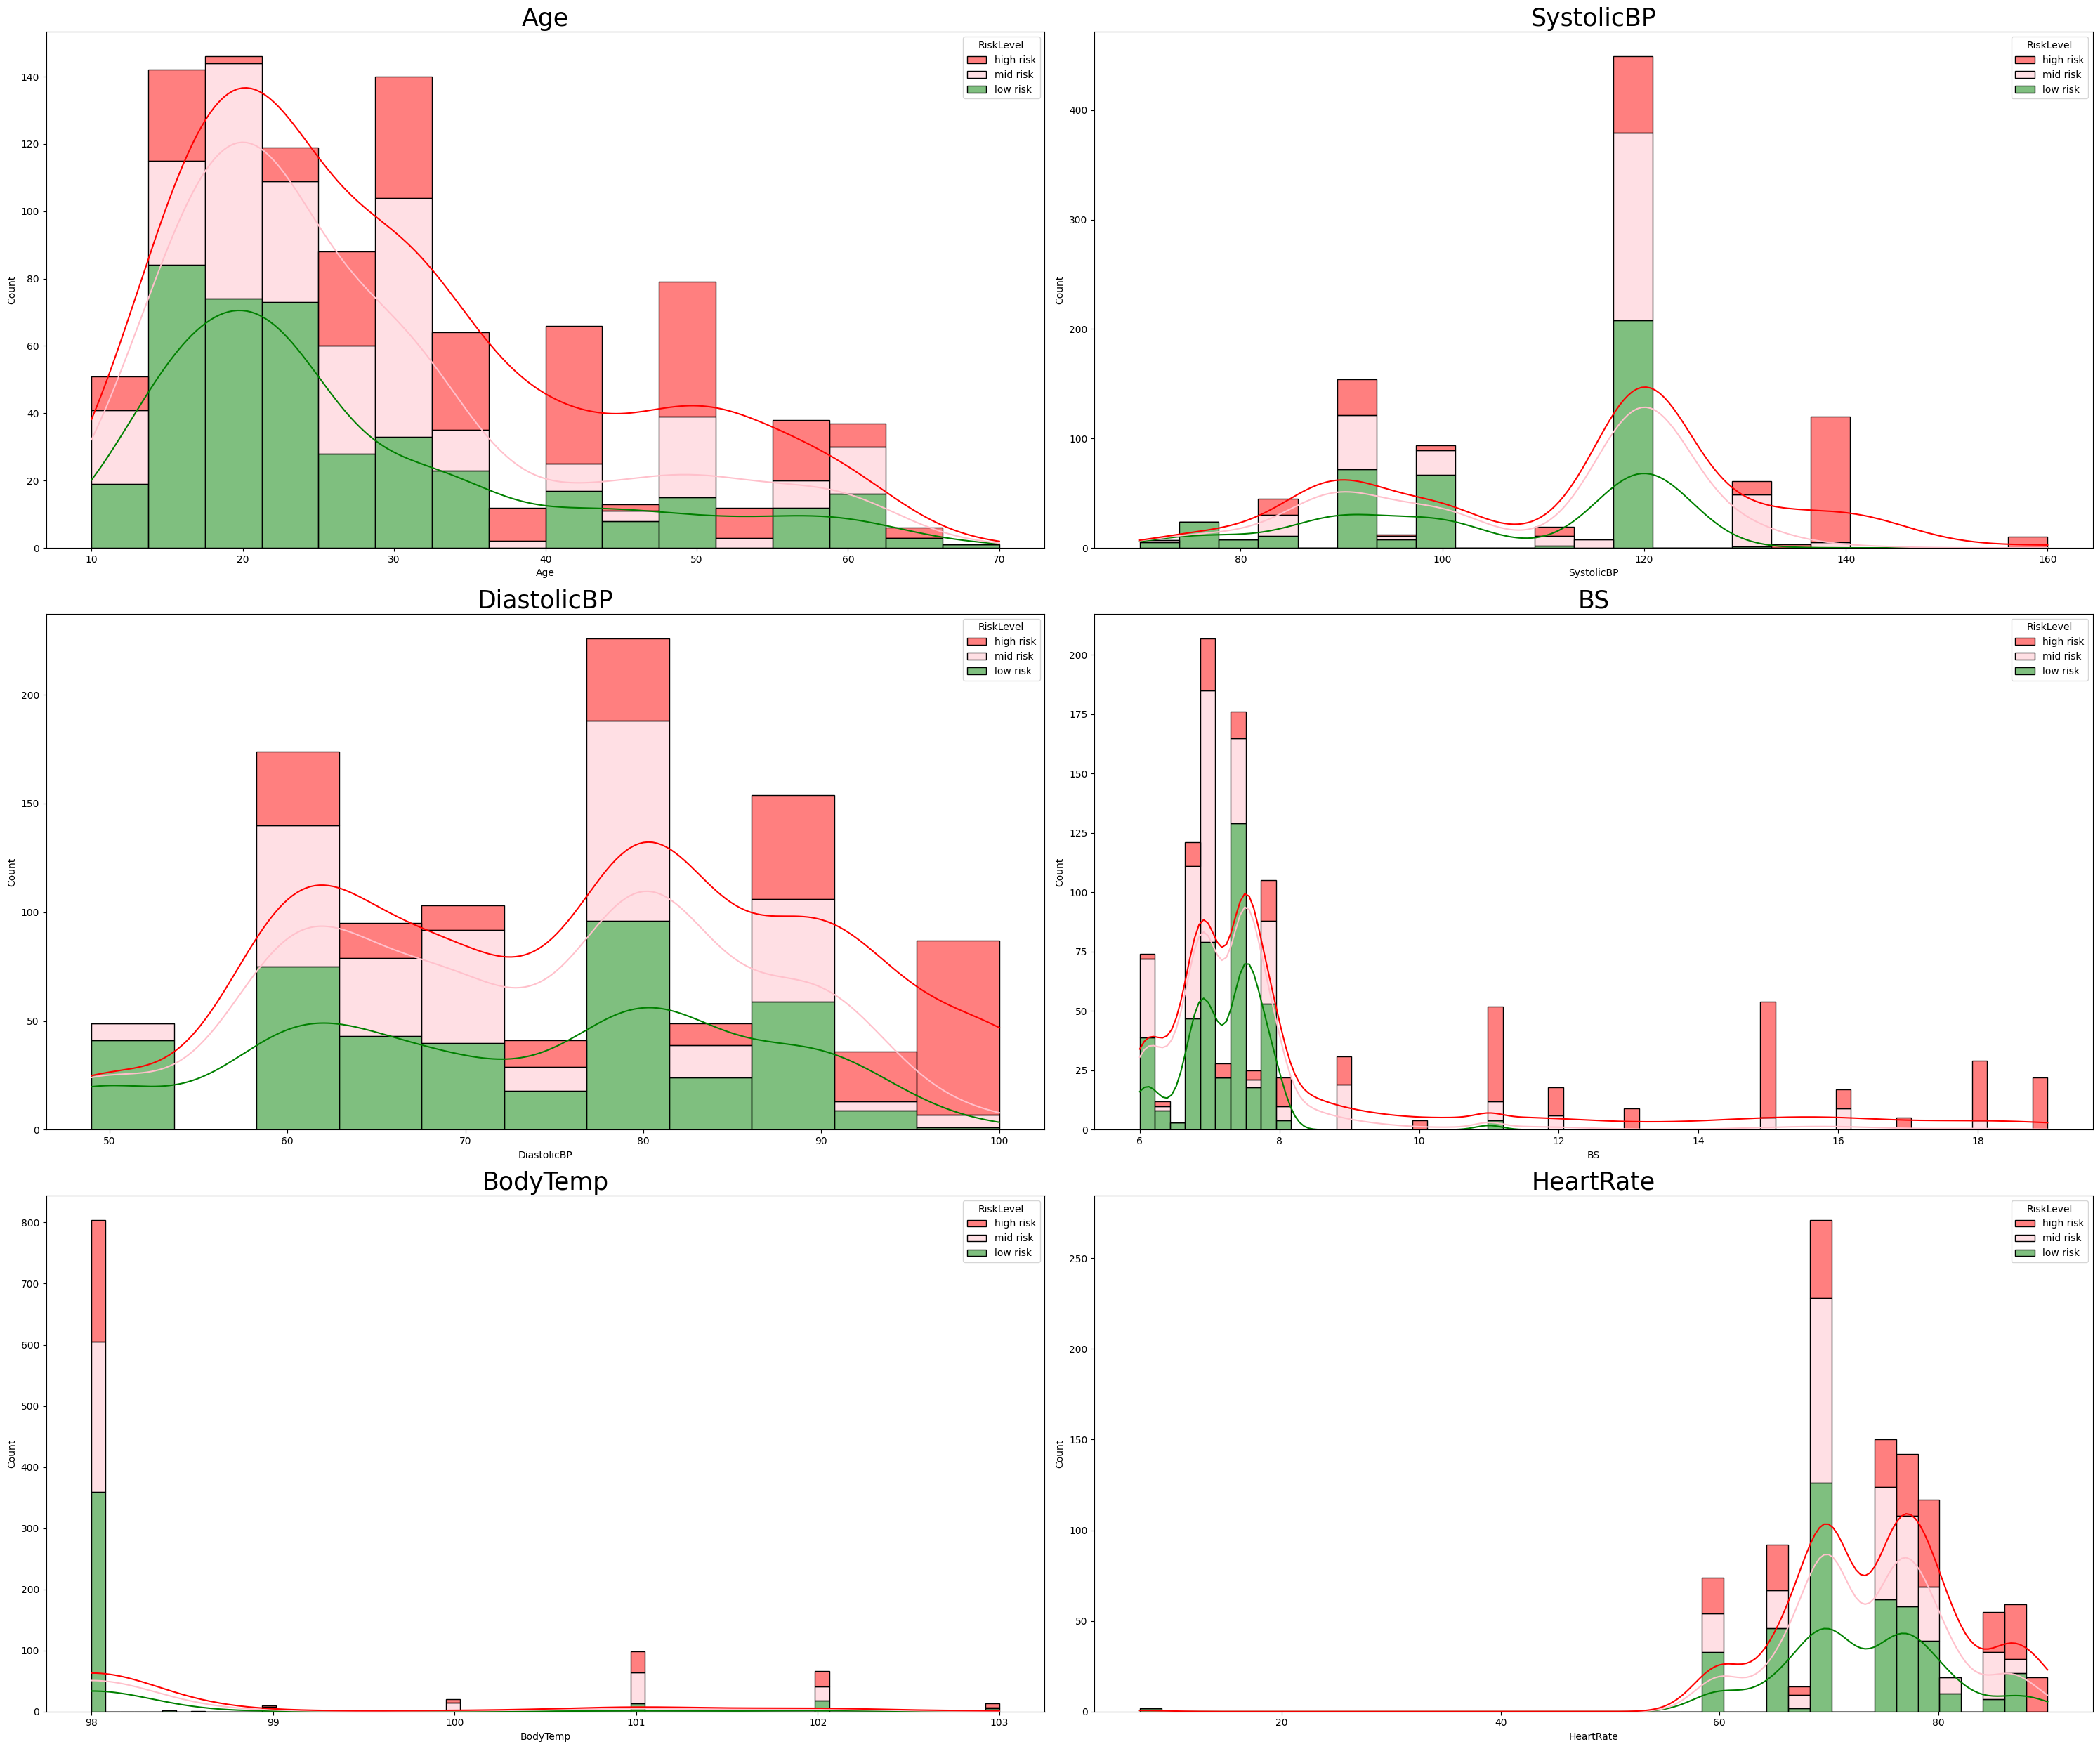

In [12]:
# Plot stacked histograms for the feature variables
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(30, 25))#helps us plot many graph in single canvas unlike single plot that we used to do
risk_level_order = ["high risk", "mid risk", "low risk"] #so we gave no of col and rows in which we want to fit data#figsize gives canvas size

for ax, column in zip(axes.flatten(), m_df.columns): #first it takes 1st column and puts in 0,0 that is age
    sns.histplot(data=m_df, #histogram is plot using seaborn library
                 x=column, #age
                 kde=True, 
                 hue="RiskLevel", #hue means kiske basis mai hum inko segregate krna chahte hai like risk ke basis pe
                 hue_order=risk_level_order, 
                 multiple="stack", #kis order mai chhaiye so ek upar ek so that is what multiple does
                 palette={"low risk": "green", "mid risk": "pink", "high risk": "red"},
                 element="bars", ax=ax)
    ax.set_title(f"{column}", fontsize=25) #set kia title jo column name hai

plt.tight_layout()
plt.savefig("maternal_features_description.png")
plt.show()  #we see that as age decreases data is less

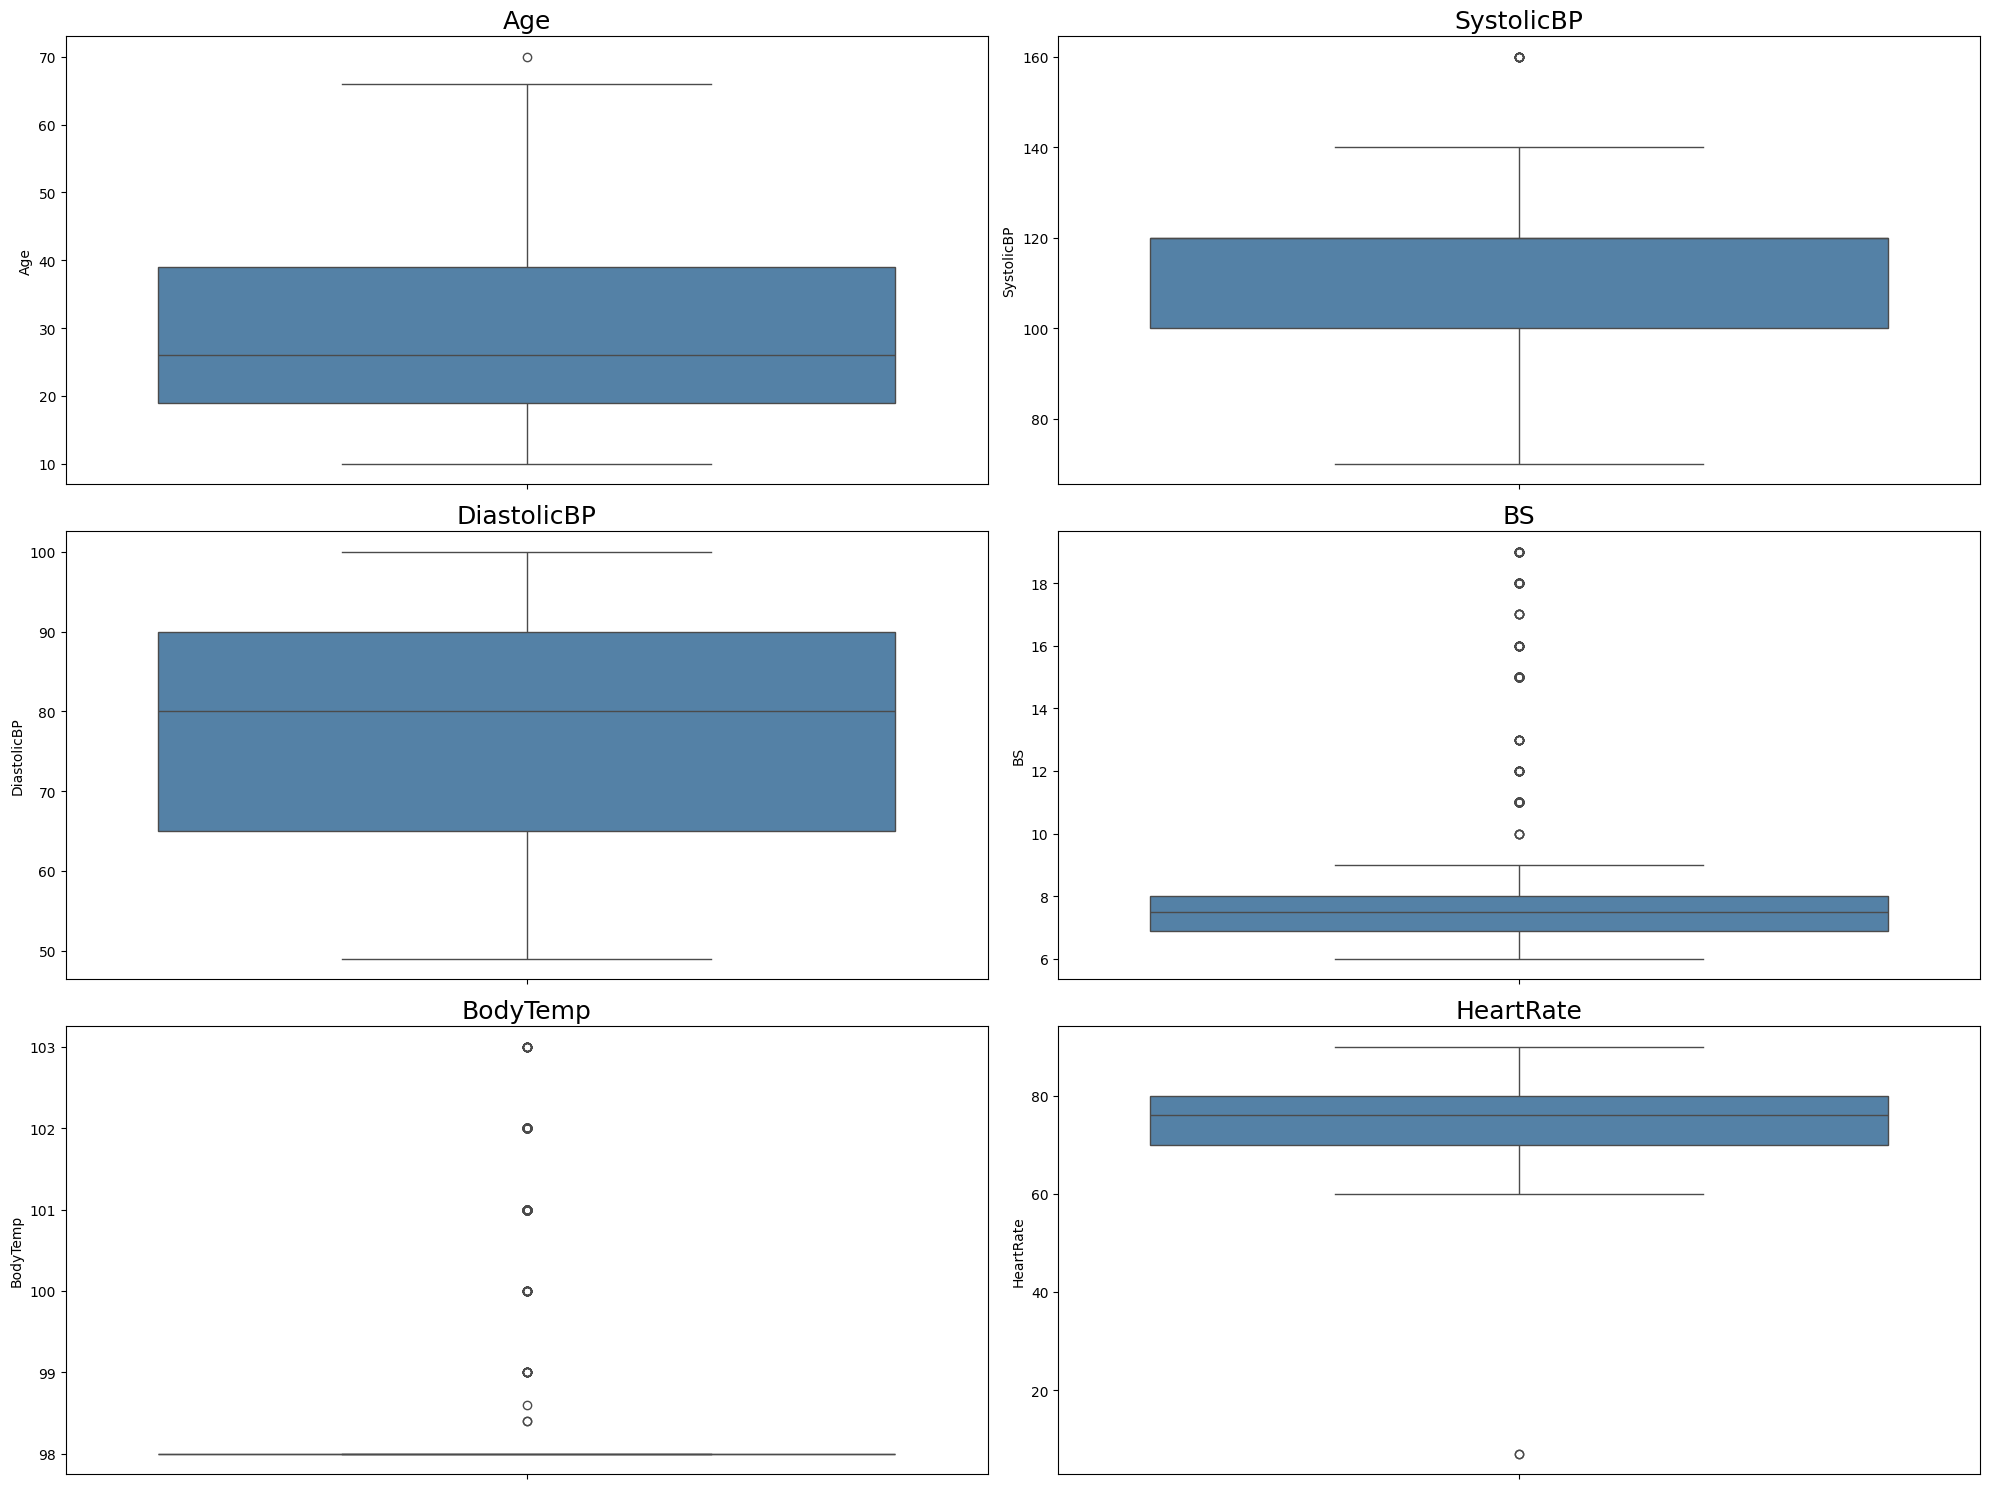

In [13]:
# Plot boxplots for the feature variables
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 15)) #boxplots is very useful in defining outliers suppose all our data was working fine but one value takes the graph upwards so might be that was an exception so it  creates a problem#boxplot helps there

for ax, column in zip(axes.flatten(), m_df.columns):
    sns.boxplot(y=m_df[column],#y=is dataset se yeh column dedo 
                color="#4682B4", 
                ax=ax)
    ax.set_title(f"{column}", fontsize=18)

plt.tight_layout()
plt.savefig("maternal_skewed_distribution_to_check_outliars.png")
plt.show() #below in plots if u see then in heartrate we have one outlier that is all data is above 60 but just one different from all so we have to remove such outliers in future

<div style="background-color:#4CAF50;
            padding:20px;
            border-radius:10px;">
<h1 style="color:white;" align="center">
Correlation Analysis Of Variables
</h1>
</div>

In [14]:
# Map RiskLevel to integer values
risk_mapping = {"low risk": 0, "mid risk": 1, "high risk": 2} #dictionary #risk level ko map kia data number ke saath
m_df["RiskLevel"] = m_df["RiskLevel"].map(risk_mapping) #ab mapped rsik level ko dataset ke saath map karre hai
m_df.info()  #correaltion means ek term dusre term mai kitna depend krti hai
#yeh karne se risk level ki data type object se change hoke integer hogai hai

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 55.6 KB


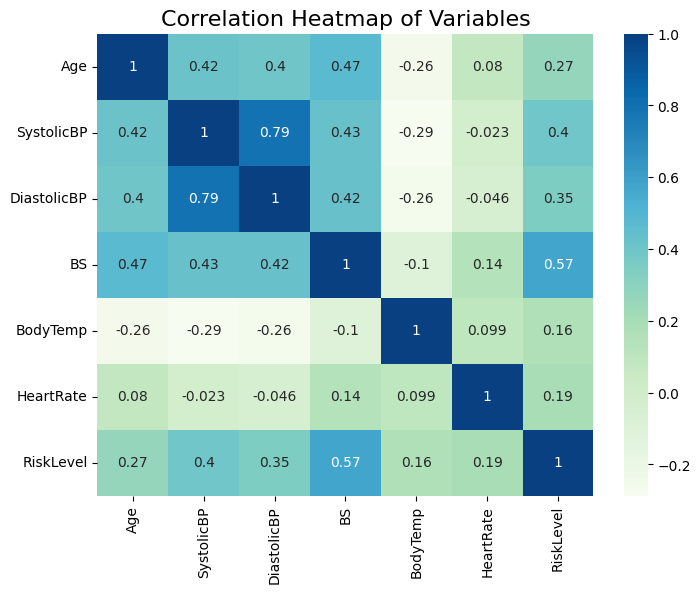

In [15]:
# Create a correlation heatmap
plt.figure(figsize=(8,6))  
sns.heatmap(m_df.corr(), annot=True, cmap = "GnBu") #annot bataega kitna percent true hai and cmap color
plt.title("Correlation Heatmap of Variables", fontsize=16)
plt.savefig("maternal_heat_map_to_check_correlation.png")
plt.show()

#generally ek increasing factor hota h#like the more u work good more is the chances of promotion 
#similar we have to see which are terms linked together and which are terms linked wth risk factor or prediction
#1 and -1 are extrems 1 means directly proportionate if smthg is increased 1 then other also will increase by 1x
#-1 means if smthg went -1 down other will go +1 up
#seeing graph from 0-axis we see blood sugar is an importand factor and beneficial as it has most correlation with risk level
#SystolicBP and DiastolicBP show a high positive correlation (correlation coefficient = 0.79), indicating multicollinearity. This suggests redundancy in information between these two variables.so we have to remove one of them for sure

In [16]:
corr = m_df.corr(numeric_only=True)
print(corr.shape)
print(corr)

(7, 7)
                  Age  SystolicBP  DiastolicBP        BS  BodyTemp  HeartRate  \
Age          1.000000    0.416045     0.398026  0.473284 -0.255323   0.079798   
SystolicBP   0.416045    1.000000     0.787006  0.425172 -0.286616  -0.023108   
DiastolicBP  0.398026    0.787006     1.000000  0.423824 -0.257538  -0.046151   
BS           0.473284    0.425172     0.423824  1.000000 -0.103493   0.142867   
BodyTemp    -0.255323   -0.286616    -0.257538 -0.103493  1.000000   0.098771   
HeartRate    0.079798   -0.023108    -0.046151  0.142867  0.098771   1.000000   
RiskLevel    0.267225    0.396473     0.346649  0.569942  0.163984   0.194312   

             RiskLevel  
Age           0.267225  
SystolicBP    0.396473  
DiastolicBP   0.346649  
BS            0.569942  
BodyTemp      0.163984  
HeartRate     0.194312  
RiskLevel     1.000000  


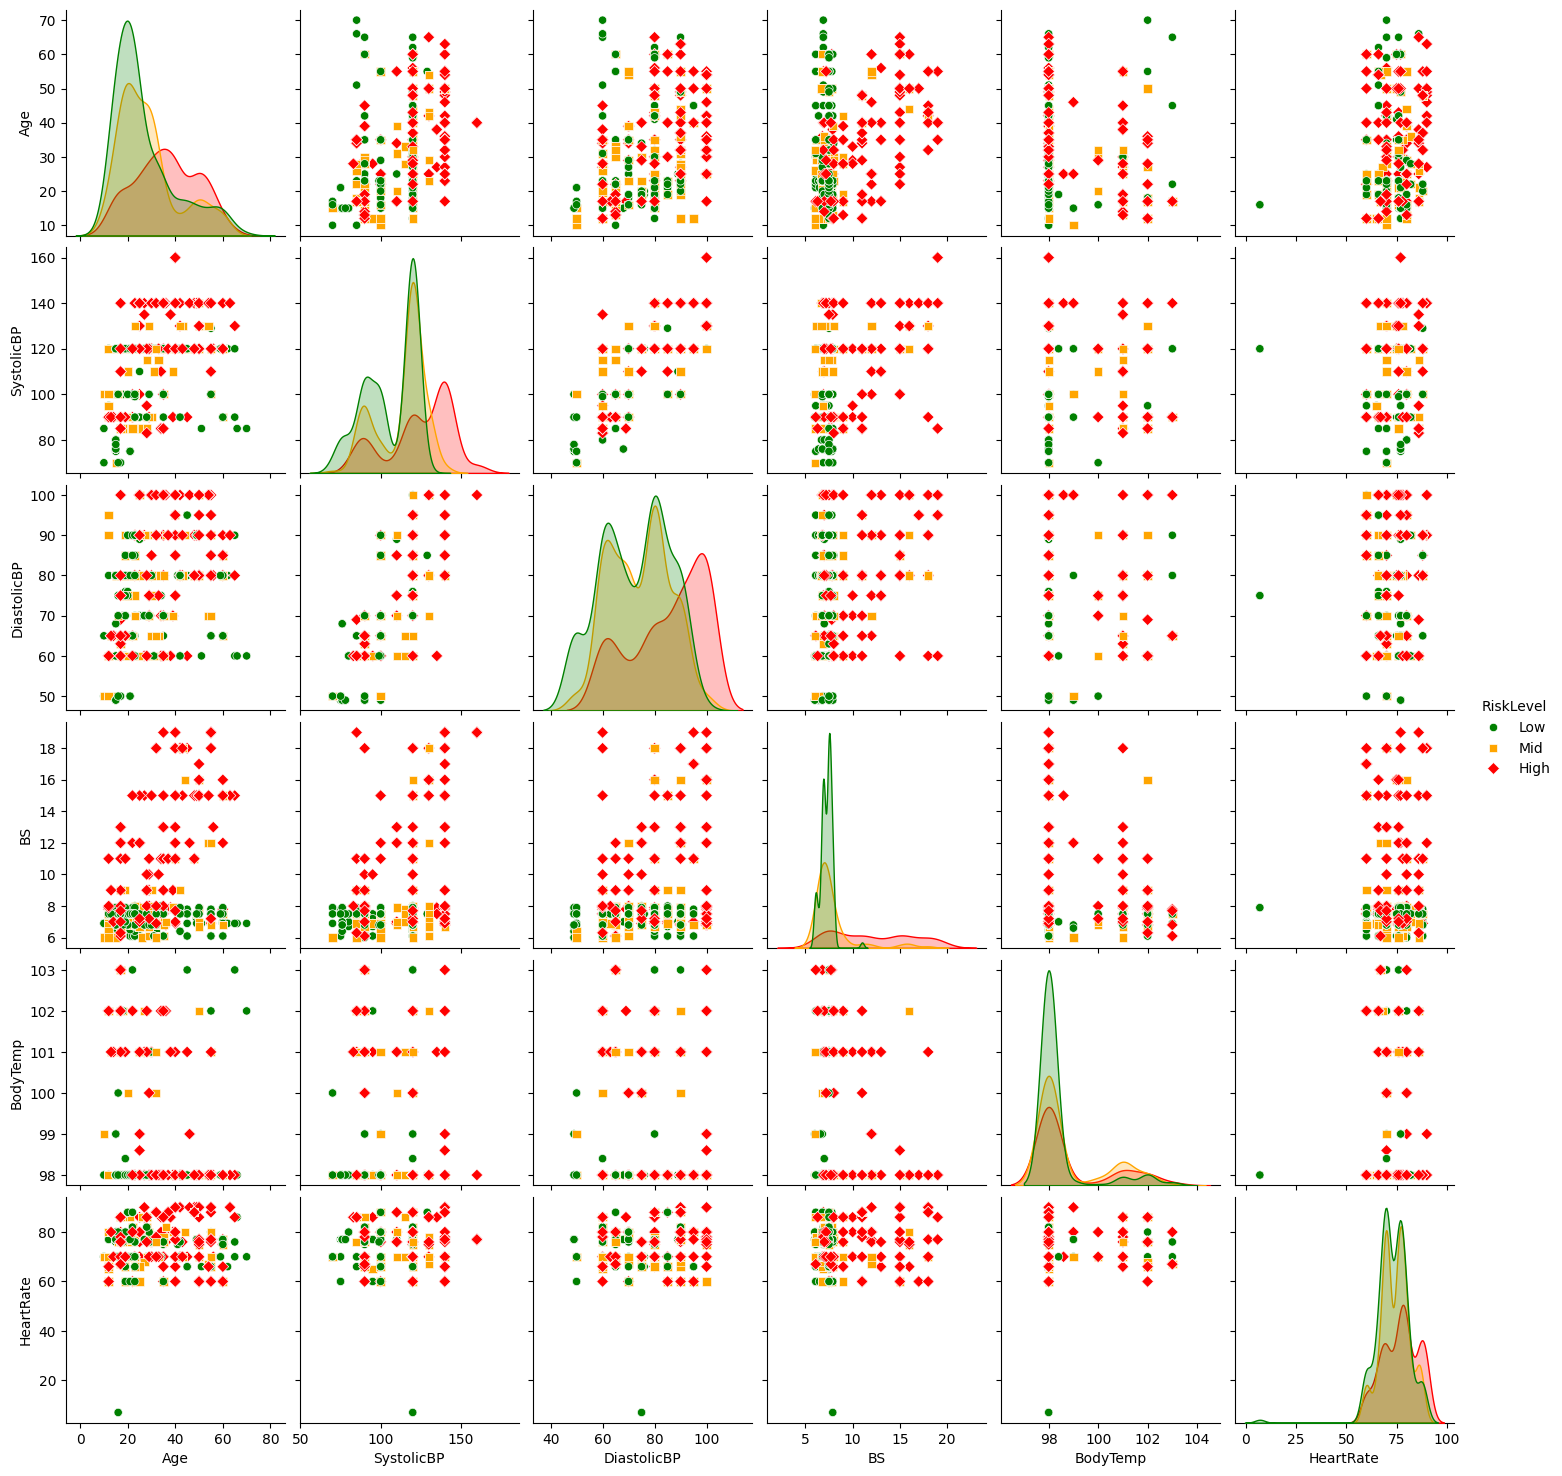

In [17]:
# Create a pairplot with RiskLevel
risk_colors = {0: "green", 1: "orange", 2: "red"}

plot = sns.pairplot(m_df, hue='RiskLevel',  #pair plot plots the graph of sabka sabke saath instead of correlation
                    palette=risk_colors, 
                    markers=["o", "s", "D"])

legend_labels = {"0": "Low", "1": "Mid", "2": "High"}
for text, label in zip(plot._legend.texts, legend_labels.values()):
    text.set_text(label)
plt.savefig("maternal_pairplot_to_see_patterns.png")
plt.show()


In [18]:
# Dealing with multicollinearity
# Variance Inflation Factor (VIF) calculation
#variation inflation factor is like ek ke increase hone se dusra kitna increase hora hai
#we just verified that vif for both BP is same as said above so remove it
X = m_df[["SystolicBP", "DiastolicBP"]]
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data


,Variable,VIF
0,SystolicBP,79.96833
1,DiastolicBP,79.96833


In [19]:
# Drop SystolicBP for model training
m_df = m_df.drop(["SystolicBP"], axis=1)

In [20]:
# Identify the outlier in HeartRate
m_df.HeartRate.sort_values().head()
#heart rate mai bhi hume upar outlier dikhra tah toh humne sort krke dekha toh pta chala sirf do hi 7 h or baaki sab toh start hi 60 se hori h so outlier delete krdete hai

499      7
908      7
1000    60
1010    60
705     60
Name: HeartRate, dtype: int64

In [21]:
# Remove the outlier in HeartRate
m_df = m_df.drop(m_df.index[m_df.HeartRate == 7])

In [22]:
m_df.info()
#yaha tak data preparation hogya now from below we will feed the data

<class 'pandas.core.frame.DataFrame'>
Index: 1012 entries, 0 to 1013
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1012 non-null   int64  
 1   DiastolicBP  1012 non-null   int64  
 2   BS           1012 non-null   float64
 3   BodyTemp     1012 non-null   float64
 4   HeartRate    1012 non-null   int64  
 5   RiskLevel    1012 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 55.3 KB


<div style="background-color:#4CAF50;
            padding:20px;
            border-radius:10px;">
<h1 style="color:white;" align="center">
Model Building
</h1>
</div>

In [23]:
# Feature scaling
columns = ["Age", "DiastolicBP", "BS", "BodyTemp", "HeartRate"]   #here we used features that help u sto predict we have not taken label here
scale_X = StandardScaler()                                        #intilize kia #scale x will tak eall the values and transform them such that they range from -1 to 1 #we have imported them in algorithms
X = pd.DataFrame(scale_X.fit_transform(m_df.drop(["RiskLevel"],axis = 1),), columns = columns)#here we have features so we have to transform x by removing the label and columns can be taken as defined
y = m_df["RiskLevel"]                                           #label #that is to be predicted
#in model building lets learn how can we use different models and find the best model out of them by comparing accuracy f1 score so that we can use accurate model for correct predicton out of them

In [24]:
import pickle

pickle.dump(
    scale_X,
    open("/kaggle/working/scaler_maternal_model.sav", "wb")
)

In [25]:
X.head()  #if u see below then age cant be like this but we have scaled them

,Age,DiastolicBP,BS,BodyTemp,HeartRate
0,-0.363796,0.254566,1.903633,-0.485808,1.538308
1,0.378765,0.974379,1.296644,-0.485808,-0.589878
2,-0.066772,-0.465247,-0.220828,0.972192,0.740239
3,0.007484,0.614473,-0.524323,-0.485808,-0.589878
4,0.378765,-1.185059,-0.797468,-0.485808,0.208192


In [26]:
# train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)   #test size 20% and randomly shuffle kardo now stratify adjusts the ratio of data such that there is no biasness between high low mdeium risk 
X_train.shape, X_test.shape, y_train.shape, y_test.shape
#used to train the model by given input and output so it works within itself trains oneself
#X split into 2 parts and y split into two parts#we have imported library for it also

((809, 5), (203, 5), (809,), (203,))

<div style="background-color:#4CAF50;
            padding:20px;
            border-radius:10px;">
<h1 style="color:white;" align="center">
Logistic Regression
</h1>
</div>

In [27]:
# Baseline model of Logistic Regression
logistic_regression = linear_model.LogisticRegression()#used for classification#yaha model ko name dia h
logistic_regression_mod = logistic_regression.fit(X_train, y_train)#train
print(f"Baseline Logistic Regression: {round(logistic_regression_mod.score(X_test, y_test), 3)}")
pred_logistic_regression = logistic_regression_mod.predict(X_test)#x test ka pred nikala so that we can compare ki jo actual value h that is y_test usme kya aana chahiye

Baseline Logistic Regression: 0.64


In [28]:
# Cross validate Logistic Regression model
scores_Logistic = cross_val_score(logistic_regression, X_train, y_train, cv=3, scoring="accuracy")
print(f"Scores(Cross validate) for Logistic Regression model:\n{scores_Logistic}")
print(f"CrossValMeans: {round(scores_Logistic.mean(), 3)}")
print(f"CrossValStandard Deviation: {round(scores_Logistic.std(), 3)}")

Scores(Cross validate) for Logistic Regression model:
[0.6037037  0.5962963  0.57992565]
CrossValMeans: 0.593
CrossValStandard Deviation: 0.01


In [29]:
params_LR = {"tol": [0.0001,0.0002,0.0003],
            "C": [0.01, 0.1, 1, 10, 100],
            "intercept_scaling": [1, 2, 3, 4],
            "solver": ["liblinear", "lbfgs", "newton-cg"],
            "max_iter": [100, 200, 300],
              }#parametrs given

In [30]:
GridSearchCV_LR = GridSearchCV(estimator=linear_model.LogisticRegression(), 
                                param_grid=params_LR, 
                                cv=3,
                                scoring="accuracy", 
                                return_train_score=True,
                                )#it will check all the values and try multiple combinations and permutations of value given above and check which is more accurate and use that#takes bit time

In [31]:
GridSearchCV_LR.fit(X_train, y_train);

In [32]:
print(f"Best estimator for LR model:\n{GridSearchCV_LR.best_estimator_}") #here we see the best parameters
print(f"Best parameter values for LR model:\n{GridSearchCV_LR.best_params_}")
print(f"Best score for LR model: {round(GridSearchCV_LR.best_score_, 3)}")

Best estimator for LR model:
LogisticRegression(C=0.01, solver='liblinear')
Best parameter values for LR model:
{'C': 0.01, 'intercept_scaling': 1, 'max_iter': 100, 'solver': 'liblinear', 'tol': 0.0001}
Best score for LR model: 0.602


In [33]:
# Test with new parameter
logistic_regression = linear_model.LogisticRegression(C=0.01, intercept_scaling=1, max_iter=100, solver="liblinear", tol=0.0001, random_state=42)
logistic_regression_mod = logistic_regression.fit(X_train, y_train)
pred_logistic_regression = logistic_regression_mod.predict(X_test)

mse_logistic_regression = mean_squared_error(y_test, pred_logistic_regression)
rmse_logistic_regression = np.sqrt(mean_squared_error(y_test, pred_logistic_regression))
score_logistic_regression_train = logistic_regression_mod.score(X_train, y_train)
score_logistic_regression_test = logistic_regression_mod.score(X_test, y_test)

In [34]:
print(f"Mean Square Error for Logistic Regression = {round(mse_logistic_regression, 3)}")
print(f"Root Mean Square Error for Logistic Regression = {round(rmse_logistic_regression, 3)}")
print(f"R^2(coefficient of determination) on training set = {round(score_logistic_regression_train, 3)}")
print(f"R^2(coefficient of determination) on testing set = {round(score_logistic_regression_test, 3)}")

Mean Square Error for Logistic Regression = 0.512
Root Mean Square Error for Logistic Regression = 0.716
R^2(coefficient of determination) on training set = 0.609
R^2(coefficient of determination) on testing set = 0.635


In [35]:
print("Classification Report")
print(classification_report(y_test, pred_logistic_regression))
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred_logistic_regression))

Classification Report
              precision    recall  f1-score   support

           0       0.59      0.88      0.70        81
           1       0.56      0.21      0.30        67
           2       0.77      0.80      0.79        55

    accuracy                           0.64       203
   macro avg       0.64      0.63      0.60       203
weighted avg       0.63      0.64      0.59       203

Confusion Matrix:
[[71  6  4]
 [44 14  9]
 [ 6  5 44]]


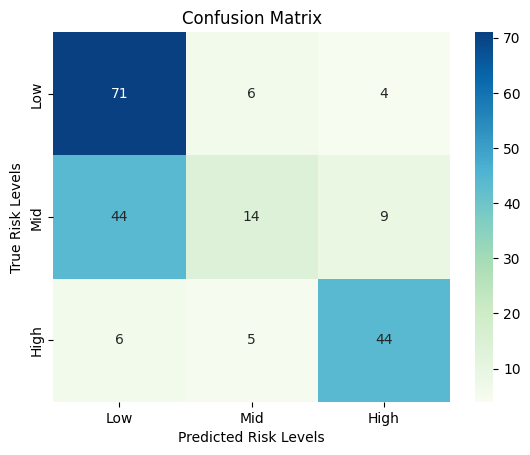

In [36]:
ax= plt.subplot() #plot confusion matrix
sns.heatmap(confusion_matrix(y_test, pred_logistic_regression), annot=True, ax=ax, cmap = "GnBu");

ax.set_xlabel("Predicted Risk Levels");
ax.set_ylabel("True Risk Levels");  
ax.set_title("Confusion Matrix"); 
ax.xaxis.set_ticklabels(["Low", "Mid", "High"]);
ax.yaxis.set_ticklabels(["Low", "Mid", "High"]); #see below 6 predictions low predict hu ah jo actual mai high hai so prob

<div style="background-color:#4CAF50;
            padding:20px;
            border-radius:10px;">
<h1 style="color:white;" align="center">
K-Nearest Neighbors
</h1>
</div>

In [37]:
# Baseline model of K-Nearest Neighbors
knn = KNeighborsClassifier() #knn ke basis mai model ko train kia
knn_mod = knn.fit(X_train, y_train)
print(f"Baseline K-Nearest Neighbors: {round(knn_mod.score(X_test, y_test), 3)}")
pred_knn = knn_mod.predict(X_test)

Baseline K-Nearest Neighbors: 0.665


In [38]:
# Cross validate K-Nearest Neighbors model
scores_knn = cross_val_score(knn, X_train, y_train, cv=3, scoring="accuracy")
print(f"Scores(Cross validate) for K-Nearest Neighbors model:\n{scores_knn}")
print(f"CrossValMeans: {round(scores_knn.mean(), 3)}")
print(f"CrossValStandard Deviation: {round(scores_knn.std(), 3)}")

Scores(Cross validate) for K-Nearest Neighbors model:
[0.61481481 0.68148148 0.62453532]
CrossValMeans: 0.64
CrossValStandard Deviation: 0.029


In [39]:
params_knn = {"leaf_size": list(range(1,30)), #yaha values ka range lenge phir niche isme se accuarate fid karenge
              "n_neighbors": list(range(1,21)),
              "p": [1,2],
              "weights": ["uniform", "distance"],
             }

In [40]:
GridSearchCV_knn = GridSearchCV(estimator=KNeighborsClassifier(),  #gridSearch kia
                                param_grid=params_knn,
                                cv=3,
                                scoring="accuracy",
                                return_train_score=True
                                )

In [41]:
# Fit model with train data
GridSearchCV_knn.fit(X_train, y_train); #value nikali #yeh harek possible premutations and combinations ko dekhke fit krta hai

In [42]:
print(f"Best estimator for KNN model:\n{GridSearchCV_knn.best_estimator_}") #values ko print kia score find kia
print(f"Best parameter values:\n{GridSearchCV_knn.best_params_}")
print(f"Best score for GNB model: {round(GridSearchCV_knn.best_score_, 3)}")

Best estimator for KNN model:
KNeighborsClassifier(leaf_size=1, n_neighbors=10, weights='distance')
Best parameter values:
{'leaf_size': 1, 'n_neighbors': 10, 'p': 2, 'weights': 'distance'}
Best score for GNB model: 0.795


In [43]:
# Test with new parameter
knn = KNeighborsClassifier(leaf_size=1, n_neighbors=10, p=2, weights="distance")
knn_mod = knn.fit(X_train, y_train)
pred_knn = knn_mod.predict(X_test)

mse_knn = mean_squared_error(y_test, pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, pred_knn))
score_knn_train = knn_mod.score(X_train, y_train)
score_knn_test = knn_mod.score(X_test, y_test)

In [44]:
print(f"Mean Square Error for K_Nearest Neighbor  = {round(mse_knn, 3)}")
print(f"Root Mean Square Error for K_Nearest Neighbor = {round(rmse_knn, 3)}")
print(f"R^2(coefficient of determination) on training set = {round(score_knn_train, 3)}")
print(f"R^2(coefficient of determination) on testing set = {round(score_knn_test, 3)}")

Mean Square Error for K_Nearest Neighbor  = 0.251
Root Mean Square Error for K_Nearest Neighbor = 0.501
R^2(coefficient of determination) on training set = 0.934
R^2(coefficient of determination) on testing set = 0.837


In [45]:
print("Classification Report")
print(classification_report(y_test, pred_knn))
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred_knn))

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.77      0.82        81
           1       0.77      0.85      0.81        67
           2       0.88      0.93      0.90        55

    accuracy                           0.84       203
   macro avg       0.84      0.85      0.84       203
weighted avg       0.84      0.84      0.84       203

Confusion Matrix:
[[62 17  2]
 [ 5 57  5]
 [ 4  0 51]]


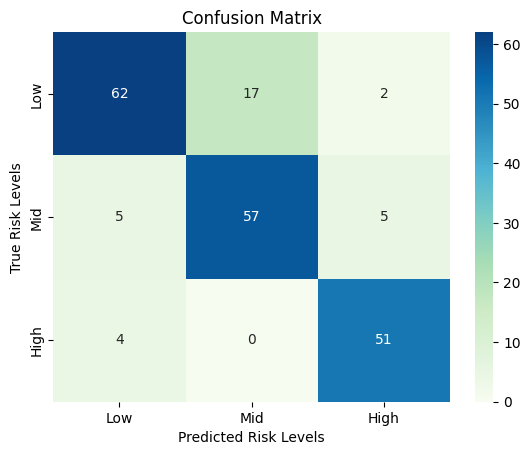

In [46]:
ax= plt.subplot()
sns.heatmap(confusion_matrix(y_test, pred_knn), annot=True, ax = ax, cmap = "GnBu");

ax.set_xlabel("Predicted Risk Levels");
ax.set_ylabel("True Risk Levels"); 
ax.set_title("Confusion Matrix"); 
ax.xaxis.set_ticklabels(["Low", "Mid", "High"]);
ax.yaxis.set_ticklabels(["Low", "Mid", "High"]);

<div style="background-color:#4CAF50;
            padding:20px;
            border-radius:10px;">
<h1 style="color:white;" align="center">
Random Forest
</h1>
</div>

In [47]:
# Baseline model of Random Forest Classifier
random_forest = RandomForestClassifier() #again same sequence
random_forest_mod = random_forest.fit(X_train, y_train)
print(f"Baseline Random Forest: {round(random_forest_mod.score(X_test, y_test), 3)}")
pred_random_forest = random_forest_mod.predict(X_test)

Baseline Random Forest: 0.833


In [48]:
# Cross validate Random Forest Classifier model
scores_RF = cross_val_score(random_forest, X_train, y_train, cv=3, scoring = "accuracy")
print(f"Scores(Cross validate) for Random forest model:\n{scores_RF}")
print(f"CrossValMeans: {round(scores_RF.mean(), 3)}")
print(f"CrossValStandard Deviation: {round(scores_RF.std(), 3)}")

Scores(Cross validate) for Random forest model:
[0.7962963  0.80740741 0.82899628]
CrossValMeans: 0.811
CrossValStandard Deviation: 0.014


In [49]:
params_RF = {"min_samples_split": [2, 6, 20],
              "min_samples_leaf": [1, 2, 4],
              "n_estimators" :[50,100,200,300,400],
              "max_depth": [None, 10, 20, 30],
              "criterion": ["gini", "entropy"]             
              }

In [50]:
GridSearchCV_RF = GridSearchCV(estimator=RandomForestClassifier(), 
                                param_grid=params_RF,
                                cv=3,
                                scoring="accuracy",
                                return_train_score=True
                                )

In [51]:
GridSearchCV_RF.fit(X_train, y_train);

In [52]:
print(f"Best estimator for RF model:\n{GridSearchCV_RF.best_estimator_}")
print(f"Best parameter values for RF model:\n{GridSearchCV_RF.best_params_}")
print(f"Best score for RF model: {round(GridSearchCV_RF.best_score_, 3)}")

Best estimator for RF model:
RandomForestClassifier(max_depth=20, n_estimators=300)
Best parameter values for RF model:
{'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best score for RF model: 0.818


In [53]:
# Test with new parameter
random_forest = RandomForestClassifier(criterion="entropy", max_depth=30, min_samples_leaf=1, min_samples_split=2, n_estimators=200, random_state=42)
random_forest_mod = random_forest.fit(X_train, y_train)
pred_random_forest = random_forest_mod.predict(X_test)

mse_random_forest = mean_squared_error(y_test, pred_random_forest)
rmse_random_forest = np.sqrt(mean_squared_error(y_test, pred_random_forest))
score_random_forest_train = random_forest_mod.score(X_train, y_train)
score_random_forest_test = random_forest_mod.score(X_test, y_test)

In [54]:
print(f"Mean Square Error for Random Forest = {round(mse_random_forest, 3)}")
print(f"Root Mean Square Error for Random Forest = {round(rmse_random_forest, 3)}")
print(f"R^2(coefficient of determination) on training set = {round(score_random_forest_train, 3)}")
print(f"R^2(coefficient of determination) on testing set = {round(score_random_forest_test, 3)}")

Mean Square Error for Random Forest = 0.236
Root Mean Square Error for Random Forest = 0.486
R^2(coefficient of determination) on training set = 0.934
R^2(coefficient of determination) on testing set = 0.837


In [55]:
print("Classification Report")
print(classification_report(y_test, pred_random_forest))
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred_random_forest))

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.79      0.82        81
           1       0.79      0.79      0.79        67
           2       0.87      0.96      0.91        55

    accuracy                           0.84       203
   macro avg       0.84      0.85      0.84       203
weighted avg       0.84      0.84      0.84       203

Confusion Matrix:
[[64 14  3]
 [ 9 53  5]
 [ 2  0 53]]


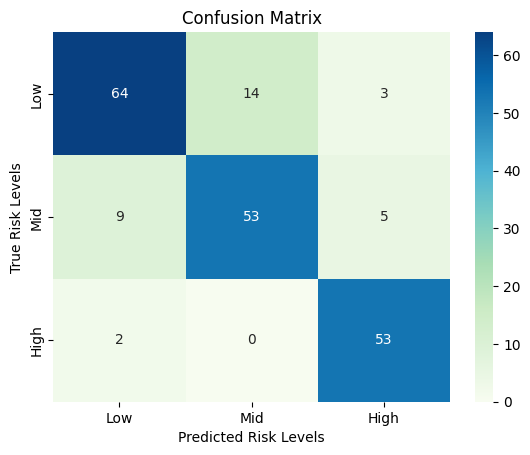

In [56]:
ax= plt.subplot()
sns.heatmap(confusion_matrix(y_test, pred_random_forest), annot=True, ax = ax, cmap = "GnBu");

ax.set_xlabel("Predicted Risk Levels");
ax.set_ylabel("True Risk Levels"); 
ax.set_title("Confusion Matrix"); 
ax.xaxis.set_ticklabels(["Low", "Mid", "High"]);
ax.yaxis.set_ticklabels(["Low", "Mid", "High"]);

<div style="background-color:#4CAF50;
            padding:20px;
            border-radius:10px;">
<h1 style="color:white;" align="center">
Gradient Boosting Classifier
</h1>
</div>

In [57]:
# Baseline model of gradient boosting classifier
gbc = GradientBoostingClassifier()
gbc_mod = gbc.fit(X_train, y_train)
print(f"Baseline gradient boosting classifier: {round(gbc_mod.score(X_test, y_test), 3)}")
pred_gbc = gbc_mod.predict(X_test)

Baseline gradient boosting classifier: 0.783


In [58]:
# Cross validate Gradient Boosting Classifier model
scores_GBC = cross_val_score(gbc, X_train, y_train, cv=3, scoring = "accuracy")
print(f"Scores(Cross validate) for Gradient Boosting Classifier model:\n{scores_GBC}")
print(f"CrossValMeans: {round(scores_GBC.mean(), 3)}")
print(f"CrossValStandard Deviation: {round(scores_GBC.std(), 3)}")

Scores(Cross validate) for Gradient Boosting Classifier model:
[0.74814815 0.78518519 0.78810409]
CrossValMeans: 0.774
CrossValStandard Deviation: 0.018


In [59]:
params_GBC = {
    "loss": ["log_loss"],          #we replaced deviance and remove exponential
    "learning_rate": [0.01, 0.05, 0.075, 0.1],
    "n_estimators": [100, 250, 500],
    "max_depth": [3, 5, 8, 10],
    "subsample": [0.8, 1]
}

In [60]:
GridSearchCV_GBC = GridSearchCV(estimator=GradientBoostingClassifier(), 
                                param_grid=params_GBC,
                                cv=3,
                                scoring="accuracy", 
                                return_train_score=True
                                )

In [ ]:
# Fit model with train data
GridSearchCV_GBC.fit(X_train, y_train);

In [ ]:
print(f"Best estimator values for GBC model:\n{GridSearchCV_GBC.best_estimator_}")
print(f"Best parameter values for GBC model:\n{GridSearchCV_GBC.best_params_}")
print(f"Best score value foe GBC model: {round(GridSearchCV_GBC.best_score_, 3)}")

In [ ]:
# Test with new parameter
gbc = GradientBoostingClassifier(learning_rate=0.5, loss="log_loss", max_depth=10, n_estimators=100, subsample=1,random_state=42)
gbc_mod = gbc.fit(X_train, y_train)
pred_gbc = gbc_mod.predict(X_test)

mse_gbc = mean_squared_error(y_test, pred_gbc)
rmse_gbc = np.sqrt(mean_squared_error(y_test, pred_gbc))
score_gbc_train = gbc_mod.score(X_train, y_train)
score_gbc_test = gbc_mod.score(X_test, y_test)

In [ ]:
print(f"Mean Square Error for Gradient Boosting Classifier = {round(mse_gbc, 3)}")
print(f"Root Mean Square Error for Gradient Boosting Classifier = {round(rmse_gbc, 3)}")
print(f"R^2(coefficient of determination) on training set = {round(score_gbc_train, 3)}")
print(f"R^2(coefficient of determination) on testing set = {round(score_gbc_test, 3)}")

In [ ]:
print("Classification Report")
print(classification_report(y_test, pred_gbc))
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred_gbc))

In [ ]:
ax= plt.subplot()
sns.heatmap(confusion_matrix(y_test, pred_gbc), annot=True, ax = ax, cmap = "GnBu");

ax.set_xlabel("Predicted Risk Levels");
ax.set_ylabel("True Risk Levels"); 
ax.set_title("Confusion Matrix"); 
ax.xaxis.set_ticklabels(["Low", "Mid", "High"]);
ax.yaxis.set_ticklabels(["Low", "Mid", "High"]);

In [ ]:
# Create a DataFrame to store model evaluation results
results = pd.DataFrame({ #compare krne ek new dataframe banaaya and saare model names dediye and their cross value scores,test sores
    "Model": ["Logistic Regression", "K-Nearest Neighbors", "Random Forest", "Gradient Boosting Classifier"],
    "Train Score": [
        # Calculate mean cross-validated accuracy for training set
        cross_val_score(logistic_regression_mod, X_train, y_train, cv=3).mean(),
        cross_val_score(knn_mod, X_train, y_train, cv=3).mean(),
        cross_val_score(random_forest_mod, X_train, y_train, cv=3).mean(),
        cross_val_score(gbc_mod, X_train, y_train, cv=3).mean(),
    ],
    "Test Score": [
        # Calculate accuracy on the test set
        logistic_regression_mod.score(X_test, y_test),
        knn_mod.score(X_test, y_test),
        random_forest_mod.score(X_test, y_test),
        gbc_mod.score(X_test, y_test),
    ]
})
# Additional Metrics (precision, recall, F1 score)
metrics = ["precision", "recall", "f1"]
for metric in metrics:
    results[f"{metric.capitalize()}"] = [
        precision_recall_fscore_support(y_test, model.predict(X_test), average="weighted")[metrics.index(metric)]
        for model in [logistic_regression_mod, knn_mod, random_forest_mod, gbc_mod]
    ]

result_df = results.sort_values(by="Test Score", ascending=False)
result_df = result_df.set_index("Test Score")
result_df

In [ ]:
import pickle  #to save model
#In the evaluation of model performance, the Gradient Boosting Classifier emerges as the standout performer among the considered models. 
#With a test accuracy of 84.23%, it surpasses both the K-Nearest Neighbors and Random Forest models, which exhibit commendable test accuracies of 83.74% each. 
#Notably, the Gradient Boosting Classifier's test score outstrips its train score, indicating robust generalization and mitigating concerns of overfitting.
#Moreover, this model demonstrates superior precision, recall, and F1 score, reflecting a well-balanced performance across various evaluation metrics. 
#The KNN model closely follows, excelling in precision and recall, while the Random Forest model performs well but shows a slight dip in precision. Conversely, the Logistic Regression model consistently lags in all metrics, highlighting its comparatively lower effectiveness. Consequently, the Gradient Boosting Classifier stands out as the preferred choice for this classification task, offering a compelling balance between precision, recall, and overall accuracy.

In [ ]:
pickle.dump(gbc_mod, open('finalized_maternal_model.sav', 'wb')) #wb is write format #gbc model jo upar banaya tha usko save krdia#ek file open ki and usme save krdia

In [ ]:
import pickle


In [ ]:
maternal_model = pickle.load(
    open("/kaggle/working/finalized_maternal_model.sav", "rb")
)

In [ ]:
import os

print(os.listdir("/kaggle/working"))

In [ ]:
maternal_model.predict([[1,2,78,56,76]]) #array[2] means high risk value

In [ ]:
import sklearn

In [ ]:
print (sklearn.__version__) #

In [ ]:
pip install scikit-learn==1.6.1 #installed it to use in local environment